In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import torch

In [4]:
#e_loss = torch.load("/work/fl53wumy-llaae_data_new_22092025/fl53wumy-llaae_data_new-1758244802/fl53wumy-llaae_data_new-1748049607/dpa_output/dpa_autoencoder_only/v2_data/_training_data_2000-2100_50_6_50_5_1001_20_2_50_encoderislearnable_lambda0.5_bs128/dpa_ensemble_after_20_epochs_only_autoencoder_trained/train_set_ensemble_after_20_epochs/train_e_loss_time_resolved.pt")

In [12]:
# 2000-2100
#e_loss = torch.load("/work/fl53wumy-llaae_data_new_22092025/fl53wumy-llaae_data_new-1758244802/fl53wumy-llaae_data_new-1748049607/dpa_output/dpa_autoencoder_only/v2_data/_training_data_2000-2100_50_6_50_5_1001_20_2_50_encoderislearnable_lambda0.5_bs128/dpa_ensemble_after_20_epochs_only_autoencoder_trained/train_set_ensemble_after_20_epochs/train_e_loss_time_resolved.pt")

# 1850-2100
e_loss = torch.load("/work/fl53wumy-llaae_data_new_22092025/fl53wumy-llaae_data_new-1758244802/fl53wumy-llaae_data_new-1748049607/dpa_output/dpa_autoencoder_only/v2_data/_50_6_50_5_1001_20_2_50_encoderislearnable_lambda0.5_bs128/dpa_ensemble_after_20_epochs_only_autoencoder_trained/train_set_ensemble_after_20_epochs/train_e_loss_time_resolved.pt")

e_loss.shape

torch.Size([95380, 3])

In [22]:
members=20
time_steps=4769
years = int(time_steps/19)
print(years)
e_loss_reshaped = e_loss.reshape(members, time_steps, 3).permute(1, 2, 0).reshape(time_steps, 3, members)
e_loss_reshaped.shape

251


torch.Size([4769, 3, 20])

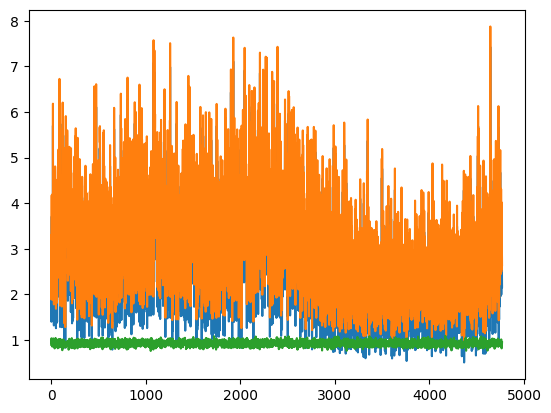

In [23]:
plt.plot(e_loss_reshaped[:,0, 0])
#plt.show()
plt.plot(e_loss_reshaped[:,1, 0])
#plt.show()
plt.plot(e_loss_reshaped[:,2, 0])
plt.show()

In [24]:
e_loss_ens_mean = e_loss_reshaped.mean(dim=2)
e_loss_ens_mean.shape

torch.Size([4769, 3])

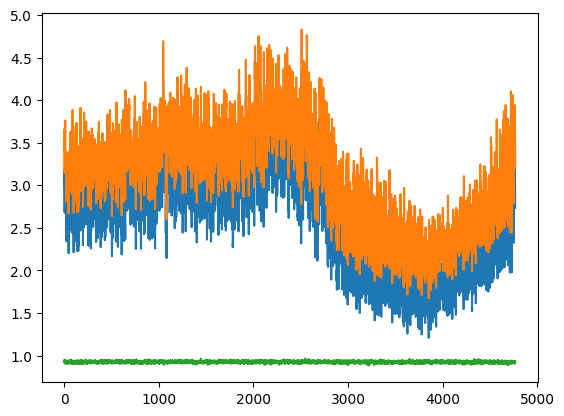

In [25]:
plt.plot(e_loss_ens_mean[:,0])
plt.plot(e_loss_ens_mean[:,1])
plt.plot(e_loss_ens_mean[:,2])
plt.show()

In [27]:
x_mean = e_loss_ens_mean.reshape(years, 19, 3).mean(dim=1)
x_mean.shape

torch.Size([251, 3])

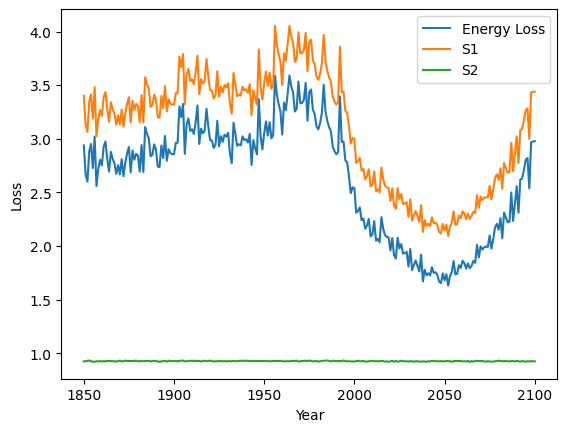

In [30]:
plt.plot(range(1850, 2101), x_mean[:,0], label = "Energy Loss")
plt.plot(range(1850, 2101), x_mean[:,1], label = "S1")
plt.plot(range(1850, 2101), x_mean[:,2], label = "S2")
plt.legend()
plt.xlabel("Year")
plt.ylabel("Loss")
plt.savefig("e_loss_1850-2100.png")
plt.show()

# plot standardized?

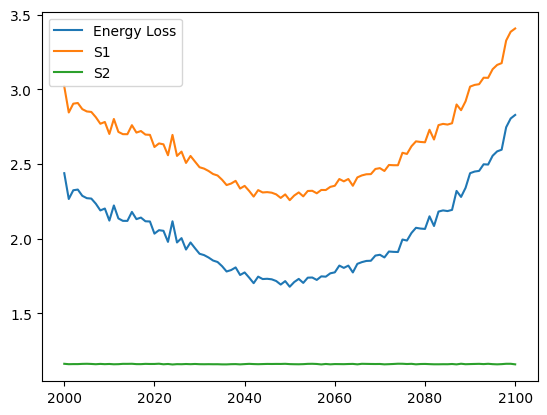

In [10]:
plt.plot(range(2000, 2101), (x_mean[:,1]-0.5*x_mean[:,2]), label = "Energy Loss")
plt.plot(range(2000, 2101), x_mean[:,1], label = "S1")
plt.plot(range(2000, 2101), x_mean[:,2], label = "S2")
plt.legend()
